In [5]:
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage,HumanMessage,BaseMessage
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from dotenv import load_dotenv
from ddgs import DDGS
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from typing import TypedDict,Annotated

load_dotenv()

True

In [6]:
llm=ChatGroq(
    model='openai/gpt-oss-20b'
)

In [7]:
#tools
#search_tool
@tool
def search_tool(query:str)->str:
    """Search the web using DuckDuckGo."""
        
    results = DDGS().text(query, max_results=5)

    if not results:
        return "No search results found."

    return "\n\n".join(
        f"Title: {r['title']}\n"
        f"URL: {r['href']}\n"
        f"Snippet: {r['body']}"
        for r in results
    )

In [8]:
@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}

In [ ]:
import os
import requests
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("FINNHUB_API_KEY")

url = "https://finnhub.io/api/v1/quote"

params = {
    "symbol": "AAPL",
    "token": API_KEY
}

response = requests.get(url, params=params)

print("Status:", response.status_code)
print("Response:")
print(response.json())

Status: 200
Response:
{'c': 333.69, 'd': 3.37, 'dp': 1.0202, 'h': 334.54, 'l': 330.61, 'o': 333.26, 'pc': 330.32, 't': 1790971200}


In [18]:
#get stock price tool
API_KEY = os.getenv("FINNHUB_API_KEY")
@tool
def get_stock_price(symbol:str)->dict:
    """
    Get the latest stock price information for a US stock symbol.

    Example symbols:
    AAPL, MSFT, GOOGL, AMZN, TSLA, NVDA
    """

    url = "https://finnhub.io/api/v1/quote"

    params = {
        "symbol": "AAPL",
        "token": API_KEY
    }

    response = requests.get(url, params=params)

    return response.json()
    


In [26]:
tools=[search_tool,calculator,get_stock_price]
llm_with_tools=llm.bind_tools(tools)

In [27]:
#state
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [43]:
def chat_node(state:ChatState):
    """llm that may answer or request a tool call"""
    response=llm_with_tools.invoke(state['messages'])
    return {'messages':[response]}

#tool node
tool_node=ToolNode(tools)

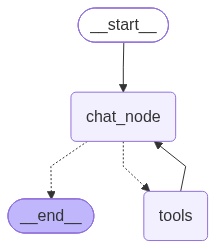

In [44]:
# build graph

graph=StateGraph(ChatState)

graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tools_condition)
graph.add_edge('tools','chat_node')

chatbot=graph.compile()
chatbot

In [45]:
response=chatbot.invoke(
    {
        'messages':[HumanMessage(content='hello')]
    }
)
response

{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='a479b689-c9c2-49ba-a058-482d73e38152'),
  AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user just says "hello". We should respond politely, maybe ask how we can help. No tool usage needed.'}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 218, 'total_tokens': 263, 'completion_time': 0.051898648, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.012541741, 'prompt_tokens_details': None, 'queue_time': 0.368852213, 'total_time': 0.064440389}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_996f667773', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a10067-b456-71f0-afae-d804d1ebad0a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 218, 'output_tokens': 45, 'total_tokens': 263, 'output_token

In [46]:
response=chatbot.invoke(
    {
        'messages':[HumanMessage(content='What is 2*3?')]
    }
)
response

{'messages': [HumanMessage(content='What is 2*3?', additional_kwargs={}, response_metadata={}, id='d9fecf26-21aa-4ee7-9eeb-d017d543b262'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to perform arithmetic: 2*3 = 6. Use calculator function.', 'tool_calls': [{'id': 'fc_f20c0dc0-583f-4aae-92cc-7635ce8d102a', 'function': {'arguments': '{"first_num":2,"operation":"mul","second_num":3}', 'name': 'calculator'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 224, 'total_tokens': 276, 'completion_time': 0.056964299, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.010901576, 'prompt_tokens_details': None, 'queue_time': 0.369310559, 'total_time': 0.067865875}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_92d51d08e5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a10067-bcf3-77e3-92d6-ddcb6b13107b-0', too

In [47]:
response=chatbot.invoke(
    {
        'messages':[HumanMessage(content="What is Apple's current stock price?")]
    }
)
response

{'messages': [HumanMessage(content="What is Apple's current stock price?", additional_kwargs={}, response_metadata={}, id='882409aa-9c65-4581-97f5-abf5498716d3'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "User asks for Apple's current stock price. We need to use the get_stock_price function.", 'tool_calls': [{'id': 'fc_42522773-2e7e-4220-8839-246462acc2b7', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 224, 'total_tokens': 268, 'completion_time': 0.04632818, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.015414297, 'prompt_tokens_details': None, 'queue_time': 0.333472559, 'total_time': 0.061742477}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_24bfb4a850', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a10067-e263-7231-a13c-

In [48]:
response=chatbot.invoke(
    {
        'messages':[HumanMessage(content="Searh and tell me who is the winner of bangladesh vs Indonesia football match?")]
    }
)
response

{'messages': [HumanMessage(content='Searh and tell me who is the winner of bangladesh vs Indonesia football match?', additional_kwargs={}, response_metadata={}, id='524b2b39-6306-4a02-92f8-cd9e02168c25'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to search the web. Use search_tool.', 'tool_calls': [{'id': 'fc_73c04478-4063-4a3b-af4d-b4900d9fe4cf', 'function': {'arguments': '{"query":"Bangladesh vs Indonesia football match winner"}', 'name': 'search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 235, 'total_tokens': 276, 'completion_time': 0.042374199, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.011560477, 'prompt_tokens_details': None, 'queue_time': 0.342126879, 'total_time': 0.053934676}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8d13edce1d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, i

In [55]:
for i in response['messages']:
    print(i.content)

Searh and tell me who is the winner of bangladesh vs Indonesia football match?

Title: Indonesia vs Bangladesh live score, H2H and lineups | Sofascore
URL: https://www.sofascore.com/football/match/bangladesh-indonesia/EWbsFwc
Snippet: On Sofascore livescore you can find all previous Indonesia vs Bangladesh results sorted by their H2H matches. Sofascore also provides the best way to follow the live score of this game with various sports features. Therefore, you can: Find out who scored in a live match Get real-time information on which team is dominating the match using the Attack Momentum Follow detailed statistics such as ...

Title: Bangladesh Vs Indonesia FIFA ASEAN Cup 2026 Match Result | Indonesia ...
URL: https://www.thedailystar.net/sports/football/news/indonesia-hammer-bangladesh-9-2-seal-final-spot-4288026
Snippet: USA-based striker Mitchell Baker scored four goals as Bangladesh suffered a 9-2 defeat against Indonesia in their final FIFA ASEAN Cup fixture at the Gelora Bung Ka

In [57]:
response['messages'][-1].content

'The most recent Bangladesh vs. Indonesia senior‑men football match was played during the 2026 FIFA ASEAN Cup.  Indonesia won decisively, beating Bangladesh **9–2**.  Hence, **Indonesia** is the winner of that encounter.'